
## Partial run of the simulation

1. Get excitement from the provided FDM simulation data.
2. Cut the excitation data to only 1m, 5m and 10m rail length answers
3. Run simulation only with the vertical excitation component
4. Compare the results with the older simulation results
5. If the simulation looks good, then build total excitation
6. Run the simulation with the total excitation

If the results look good, ready to parallelize and run the full simulation with all the excitation components.

In [42]:
import numpy as np
from rolland.database.rail.db_rail import UIC60
from utils import interpolate_contour_2d, create_mesh, calculate_centre_and_area_triangles, calculate_projected_area, \
    assign_v_to_points, vector_deflection_total

## Step 1
Get excitement from the provided FDM simulation data.

In [43]:
u_y_pos_1 = np.load('provided_data/u_y_exc_at_pos1.npy').astype(np.float16)
u_y_pos_2 = np.load('provided_data/u_y_exc_at_pos2.npy').astype(np.float16)
u_z_pos_1 = np.load('provided_data/u_z_exc_at_pos1.npy').astype(np.float16)
u_z_pos_2 = np.load('provided_data/u_z_exc_at_pos2.npy').astype(np.float16)
phi_x_pos1 = np.load('provided_data/phi_x_exc_at_pos1.npy').astype(np.float16)
phi_x_pos2 = np.load('provided_data/phi_x_exc_at_pos2.npy').astype(np.float16)

## Step 2
Create the rail mesh of monopoles

In [44]:
rail_geometry = UIC60.rl_geo
length = 65.6
rail_geometry = interpolate_contour_2d(rail_geometry, 50)
triangle_coords, triangle_index = create_mesh(rail_geometry,
                                              mesh_size=0.05,
                                              L=length  #146.0
                                              )

A, centre, norm = calculate_centre_and_area_triangles(triangle_coords, triangle_index)
print(f'mean area = {A.mean()}')
projected_area = calculate_projected_area(A, norm, 1)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (Line)
Info    : [ 10%] Meshing curve 10 (Line)
Info    : [ 10%] Meshing curve 11 (Line)
Info    : [ 10%] Meshing curve 12 (Line)
Info    : [ 10%] Meshing curve 13 (Line)
Info    : [ 10%] Meshing curve 14 (Line)
Info    : [ 10%] Meshing curve 15 (Line)
Info    : [ 20%] Meshing curve 16 (Line)
Info    : [ 20%] Meshing curve 17 (Line)
Info    : [ 20%] Meshing curve 18 (Line)
Info    : [ 20%] Meshing curve 19 (Line)
Info    : [ 20%] Meshing curve 20 (Line)
Info    : [ 20%] Meshing curve 21 (Line)
Info    : [ 20%] Meshing curve 22 (Line)
Info    : [ 20%] Meshing curve 23 (Line)
Info    : [ 20%] Meshing curve 24 (Line)
I

Info    : [ 10%] Meshing surface 109 (Surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 113 (Surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 117 (Surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 121 (Surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 125 (Surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 129 (Surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 133 (Surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 137 (Surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 141 (Surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 145 (Surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 149 (Surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 153 (Surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 157 (Surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 161 (Surface, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 165 (Surface, Frontal-Delaunay)
Info    : [ 40%] Meshing 

## Step 3
Simulate only for the vertical excitation component of the vertical excitation

In [45]:
#fist we cut the excitation respond to the 5 meter that we need
#excitation point: 0.65*50 + 0.65/2
#The 5 meter that we want to simulate is excitation_point ± 2.5
#each discrete point is 0.05m, so we would need to cut the matrice from:
#(excitation_point - 2.5)/0.05 to (excitation_point + 2.5)/0.05

excitation_point = 0.65 * 50 + 0.65 / 2
start_index = int((excitation_point - (length / 2)) / 0.05)
end_index = int((excitation_point + (length / 2)) / 0.05)

print(f'excitation point = {excitation_point} '
      f'start_index = {start_index} '
      f'end_index = {end_index}')


excitation point = 32.825 start_index = 0 end_index = 1312


In [46]:
vert_exc_vert_resp = u_z_pos_1[0::2, start_index:end_index]
print(vert_exc_vert_resp.shape)

(50000, 1286)


In [47]:
import scipy as sp
f_sim_axis = sp.fft.rfftfreq(vert_exc_vert_resp.shape[0], 0.5e-5)
vert_exc_vert_resp_v = sp.fft.rfft(vert_exc_vert_resp, norm='forward', axis=0) * 2
print(f_sim_axis.shape)
f_min = 100,
f_max = 3000
frequncy_mask = (f_sim_axis >= f_min) & (f_sim_axis <= f_max)
vert_exc_vert_resp_v = vert_exc_vert_resp_v[frequncy_mask, :]
omega = 2 * np.pi * f_sim_axis[frequncy_mask]
vert_exc_vert_resp_v = (1j * omega[:, None]) * vert_exc_vert_resp_v
nx = vert_exc_vert_resp_v.shape[1]
dx = 0.05
x_axis = np.arange(nx) * dx + (start_index * 0.05)
print(f'nx: {nx} '
      f'dx: {dx} '
      f'starting_point: {start_index * 0.05}')
triangle_v_fd = assign_v_to_points(
    x_axis,
    vert_exc_vert_resp_v.T,
    centre
)
print(triangle_v_fd.max())



(25001,)
nx: 1286 dx: 0.05 starting_point: 0.0
(0.0019217195294679568-0.0003553602327610435j)


In [48]:
from utils import run_simulation_semi_circle
from frequency_domain import monopole_multi_fa__calcf__outf

semi_circle_centre = np.array((-0.71, -0.08, 35))
P = run_simulation_semi_circle(circle_centre=semi_circle_centre,
                               circle_radius=2.5,
                               number_of_points=10,
                               simulation_function=monopole_multi_fa__calcf__outf,
                               V_fd=triangle_v_fd,
                               freqs=f_sim_axis[frequncy_mask],
                               X=centre,
                               A=projected_area[:, None], )

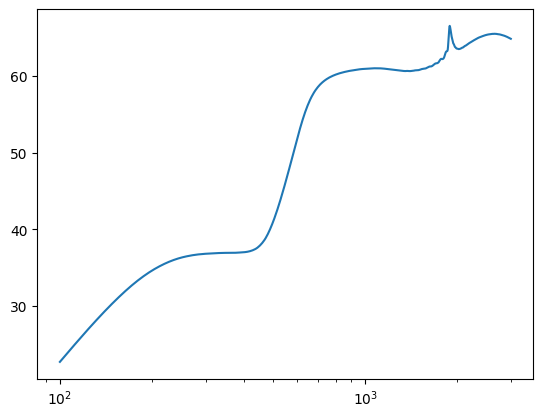

In [49]:
from matplotlib import pyplot as plt

p0 = 2e-5
P_db = 20 * np.log10((np.abs(P) + p0) / p0)
plt_mask = (f_sim_axis[frequncy_mask] >= 100) & (f_sim_axis[frequncy_mask] <= 3000)
plt_f_axis = f_sim_axis[frequncy_mask][plt_mask]
plt_P_db = P_db[plt_mask]
plt.plot(plt_f_axis, plt_P_db)
plt.xscale('log')
plt.show()

## Step 5

Now we build the total excitation by combining the component

In [50]:
from utils import vector_deflection_total
u_y = u_y_pos_1 + u_y_pos_2
u_z = u_z_pos_1 + u_z_pos_2
phi_x = phi_x_pos1 + phi_x_pos2

print(f'shape of u_y: {u_y.shape}'
      f'shape of u_z: {u_z.shape}'
      f'shape of phi_x: {phi_x.shape}')

u_y = u_y[0::2, start_index:end_index]
u_z = u_z[0::2, start_index:end_index]
phi_x = phi_x[0::2, start_index:end_index]

print(f'shape of u_y: {u_y.shape}'
      f'shape of u_z: {u_z.shape}'
      f'shape of phi_x: {phi_x.shape}')

u_y = sp.fft.rfft(u_y, norm='forward', axis=0) * 2
u_z = sp.fft.rfft(u_z, norm='forward', axis=0) * 2
phi_x = sp.fft.rfft(phi_x, norm='forward', axis=0) * 2

print(f'shape of u_y: {u_y.shape}'
      f'shape of u_z: {u_z.shape}'
      f'shape of phi_x: {phi_x.shape}')

u_y = u_y[frequncy_mask, :]
u_z = u_z[frequncy_mask, :]
phi_x = phi_x[frequncy_mask, :]

print(f'shape of u_y: {u_y.shape}'
      f'shape of u_z: {u_z.shape}'
      f'shape of phi_x: {phi_x.shape}')

omega = 2 * np.pi * f_sim_axis[frequncy_mask]
v_y = (1j * omega[:, None]) * u_y
v_z = (1j * omega[:, None]) * u_z
phi_x = (1j * omega[:, None]) * phi_x

print(f'shape of v_y: {v_y.shape}'
      f'shape of v_z: {v_z.shape}'
      f'shape of phi_x: {phi_x.shape}')

shape of u_y: (99999, 1286)shape of u_z: (99999, 1286)shape of phi_x: (99999, 1286)
shape of u_y: (50000, 1286)shape of u_z: (50000, 1286)shape of phi_x: (50000, 1286)
shape of u_y: (25001, 1286)shape of u_z: (25001, 1286)shape of phi_x: (25001, 1286)
shape of u_y: (726, 1286)shape of u_z: (726, 1286)shape of phi_x: (726, 1286)
shape of v_y: (726, 1286)shape of v_z: (726, 1286)shape of phi_x: (726, 1286)


In [51]:
triangle_v_y, triangle_v_z = vector_deflection_total(
    u_y,
    u_z,
    phi_x,
    centre,
)

In [52]:
# resp_y_fd = sp.fft.rfft(triangle_v_y_total, norm='forward', axis=0) * 2
# resp_z_fd = sp.fft.rfft(triangle_v_z_total, norm='forward', axis=0) * 2

In [53]:
# #filter to needed frequency spectrum
# resp_y_fd = resp_y_fd[frequncy_mask, :]
# resp_z_fd = resp_z_fd[frequncy_mask, :]

In [54]:
# omega = 2 * np.pi * f_sim_axis[frequncy_mask]
# resp_y_fd = (1j * omega[:, None]) * resp_y_fd
# resp_z_fd = (1j * omega[:, None]) * resp_z_fd

In [55]:
y_projected_area = calculate_projected_area(A, norm, 0)
z_projected_area = calculate_projected_area(A, norm, 1)

## Verticle only graph

In [63]:
from utils import run_simulation_semi_circle
from frequency_domain import monopole_multi_fa__calcf__outf

semi_circle_centre = np.array((-0.71, -0.08, excitation_point))
P = run_simulation_semi_circle(circle_centre=semi_circle_centre,
                               circle_radius=2.5,
                               number_of_points=10,
                               simulation_function=monopole_multi_fa__calcf__outf,
                               V_fd=triangle_v_z.T,
                               freqs=f_sim_axis[frequncy_mask],
                               X=centre,
                               A=z_projected_area[:, None], )

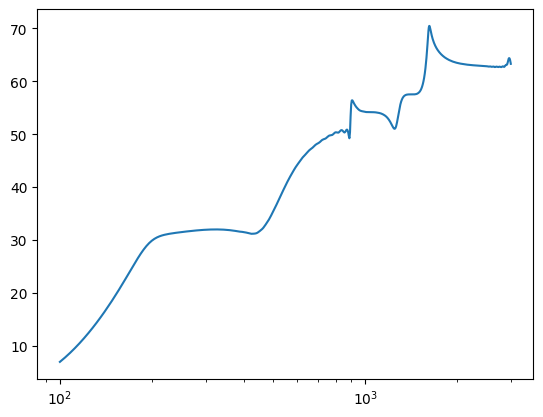

In [64]:
from matplotlib import pyplot as plt

p0 = 2e-5
P_db = 20 * np.log10((np.abs(P) + p0) / p0)
plt_mask = (f_sim_axis[frequncy_mask] >= f_min) & (f_sim_axis[frequncy_mask] <= f_max)
plt_f_axis = f_sim_axis[frequncy_mask][plt_mask]
plt_P_db = P_db[plt_mask]
plt.plot(plt_f_axis, plt_P_db)
plt.xscale('log')
plt.show()

In [65]:
from utils import run_simulation_semi_circle_total

P_total, P_z, P_y = run_simulation_semi_circle_total(
    circle_centre=semi_circle_centre,
    circle_radius=2.5,
    number_of_points=10,
    simulation_function=monopole_multi_fa__calcf__outf,
    V_fd_z=triangle_v_z.T,
    A_z=z_projected_area[:, None],
    V_fd_y=triangle_v_y.T,
    A_y=y_projected_area[:, None],
    return_components=True,
    freqs=f_sim_axis[frequncy_mask],
    X=centre,
)

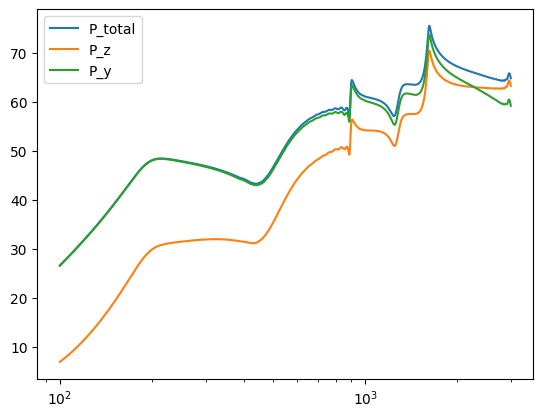

In [66]:
from matplotlib import pyplot as plt
import numpy as np

p0 = 2e-5

P_total_db = 20 * np.log10((np.abs(P_total) + p0) / p0)
P_z_db = 20 * np.log10((np.abs(P_z) + p0) / p0)
P_y_db = 20 * np.log10((np.abs(P_y) + p0) / p0)

f_plot = f_sim_axis[frequncy_mask]
plt_mask = (f_plot >= f_min) & (f_plot <= f_max)

plt_f_axis = f_plot[plt_mask]
plt_P_total_db = P_total_db[plt_mask]
plt_P_z_db = P_z_db[plt_mask]
plt_P_y_db = P_y_db[plt_mask]

plt.plot(plt_f_axis, plt_P_total_db, label="P_total")
plt.plot(plt_f_axis, plt_P_z_db, label="P_z")
plt.plot(plt_f_axis, plt_P_y_db, label="P_y")
plt.xscale('log')
plt.legend()
plt.show()